---
title: Plotando Campos de Direção em Python
short_title: Plotando Campos de Direção
date: "2026-05-24"
authors:
  - name: David Santana
tags:
  - EDO
  - Python
  - Matemática
---

# Plotando Campos de Direção em Python

<small>Publicado em 24 de maio de 2026</small>

![Campo de Direção de uma EDO super maneira que eu montei para esse exemplo](attachments/2026.2_001_plotador-campo-de-direcao.cool_edo.png)

Alguma vez durante uma sessão de leitura em um ponto de ônibus, sob um temporal molha-página-de-livro, você já se perguntou: Como Campos de Direção de EDOs são plotados em python? É..., eu também não, mas conheço pessoas que pensariam nisso.

Eu me perguntei durante a leitura do maravilhoso [Equações Diferenciais Elementares e Problemas de Valores de Contorno](https://www.amazon.com.br/Equa%C3%A7%C3%B5es-Diferenciais-Elementares-Problemas-Contorno/dp/8521636946) de William E. BOYCE, em especial na etapa de problemas propostos, depois do próprio autor informar que desenhar esses gráficos é trabalho para as máquinas.

Para colocar meus conhecimentos de python a prova depois da era do Claude Code decidi criar este notebook com as referências segui, duvidas que precisei iluminar e fontes que precisei garimpar para gerar o grafico maneiro que você está vendo acima.

# Conteúdo do notebook

Este notebook é meu rascunho de estudos de como plotar Campos de Direção de **Equações Diferenciais Ordinárias Separáveis**. Podemos agrupar o conteúdo nos seguintes tópicos:

1. Contextualização sobre Campos de Direção
2. Algorítmo para calcular e plotar o CD
3. Encapsulamento da lógica em classe python
4. Resolução dos Problemas 1.1-4 do livro do BOYCE

## Um pouco de Contexto

### O que é um Campo de Direção?

Primeiro vamos definir o que é um campo, bem, pelo menos criar um contexto básico. O primeiro contato que eu tive com campos foi em eletroestática com o **Campo Eletrico** gerado por uma carga pontual. Poderia te dar a definição formal, mas em poucas palavras um campo é um espaço vetorial, isso é, cada ponto do espaço é um vetor.

No caso de eletroestática temos que um único ponto tem apenas uma direção, por isso curvas que tangenciam esses vetores (fluxo elétrico) nunca se cortam. Pelo visto o mesmo acontece aqui em **Equações Diferenciais Ordinárias Separáveis** quando estamos tratando de Campo de Direção.

Agora que já contextualizamos o que é um campo, vamos falar sobre **Campos de Direção**. Estou assumindo que você já sabe o básico de EDOs e como as soluções são funções e não números. Basicamente o Campo de Direção é pra onde cada solução aponta.

### Para quê ele serve?

Com o campo podemos ter uma noção básica de como as soluções da EDO se comportam, mesmo sem resolver a EDO. Podemos por exemplo visualizar as **soluções de equilíbrio** da EDO e como elas interagem com seus arredores.

Além disso é bem legal poder visualizar como as soluções se comportam. Assim como o fluxo no caso do Campo Elétrico as curvas que tangenciam esses vetores são soluções particulares de uma EDO, ou pelo menos é o que me pareceu quando vi o vídeo [Divergence and curl](https://youtu.be/rB83DpBJQsE?si=xJ2sOD9eU-W-1PmK&t=272) do [3Blue1Brown](https://www.youtube.com/@3blue1brown) um tempo atrás.

Bem, vamos para uma parte mais prática e mapeada pela luz da segurança sobre o que estou falando.

## Bibliotecas Python utilizadas

**Bibliotecas**: numpy, matplotlib.

Estou usando **numpy**, o famoso np, para gerar e trabalhar com enuplas e matrizes. Já o **matplotlib** está sendo usado para plotar os gráficos em uma figura.

Estou tendo contato pela primeira vez com alguns métodos especiais, como:

- O método $np.meshgrid$, usado para criar os pares de parâmetros passados para a EDO;
- E $ax.quiver$, usado para plotar vetores (não pontos, como de costume) no gráfico

Vamos partir para o que interessa, o passo a passo para plotar um Campo de Direções.

---

# Algoritmo de criação do CP passo a passo

## Definições para antes dos cálculos

Ah, antes que eu me esqueça, por convenção a explicação de cada bloco de código vem depois do bloco de código.

```python
# Import das lib numpy para geração do mash e cálculo dos pontos
import numpy as np

# Import da lib pyplot do matplotlib para plotar o gráfico do Campo de Direção
from matplotlib import pyplot as plt
```

Antes de tudo vamos garantir que nossas libs foram importadas e estão disponíveis para o notebook.

Estou usando a boa e velha convenção de renomear *numpy* para **np** e *pyplot* para **plt**. Isso serve basicamente para evitar ter que escrever o nome completo toda vez. É muito adotado pela comunidade também, então não se assuste.

```python
# Definição da EDO via lambda function
f = lambda x, y: -2 + x + y
```

Agora definimos nossa EDO. Estamos usando a função nativa do python **lambda** para essa definição, mas para os universitários e amantes da Linguagem do Universo, a equação é definida:

$$
\frac{dy}{dx} = -2 + x + y
$$

Onde $\frac{dy}{dx}$ é a **derivada** ou **taxa de variação** de $y$ em relação à $x$; $x$ sendo a variável **independente** e $y$ a variável **dependente**.

Se você está se perguntando por que $y$ é a variável dependente, é porque $y = y(x)$, ou seja, $y$ diferentemente do real $x$ que é uma função.

```python
# Definição dos limites do gráfico
x_minimo, x_maximo = -3, 2
y_minimo, y_maximo = 1, 5

# Define a distancia entre pontos
dpx, dpy = 0.25, 0.25

# Define os intervalos para x e y
x_vals = np.arange(x_minimo, x_maximo + dpx, dpx)
y_vals = np.arange(y_minimo, y_maximo + dpy, dpy)
```

Precisamos fazer algumas definições que serão importantes para montar a estrutura do gráfico, como seus limites, distância entre pontos e os consequentes intervalos para $x$ e $y$.

```python
# Cria a mesh, pares de todas as combinações das variáveis x e y
X, Y = np.meshgrid(x_vals, y_vals)
```

E por fim geramos todos os possíveis pares de valores de $x$ e $y$ que serão plugados na nossa EDO usando a função $np.meshgrid$.

É a primeira vez que estou usando essa função, e para falar a verdade não entendi logo de cara o que ela faz. No final do notebook eu tenho alguns comentários e links de referência para quem estiver no mesmo barco.

In [50]:
# Import das lib numpy para geração do mash e cálculo dos pontos
import numpy as np

# Import da lib pyplot do matplotlib para plotar o gráfico do Campo de Direção
from matplotlib import pyplot as plt

# Definição da EDO via lambda function
f = lambda x, y: -2 + x + y

# Definição dos limites do gráfico
x_minimo, x_maximo = -3, 2
y_minimo, y_maximo = 1, 5

# Define a distancia entre pontos
dpx, dpy = 0.25, 0.25

# Define os intervalos para x e y
x_vals = np.arange(x_minimo, x_maximo + dpx, dpx)
y_vals = np.arange(y_minimo, y_maximo + dpy, dpy)

# Cria a mesh, pares de todas as combinações das variáveis x e y
X, Y = np.meshgrid(x_vals, y_vals)

É isso que temos juntando tudo.

## Calculo dos valores da função

Como estamos tratando de uma equação diferencial (EDO) na forma separáda temos: $\frac{dy}{dx} = f(x, y)$.

Já construimos a função $f(x, y)$ anteriormente e também já calculamos os pares $x$ e $y$. O que precisamos fazer agora é calcular o retorno de $f$ para cada par de entradas.

Para construir um Campo de Direção vamos plotar um segmento de reta para cada valor calculado de $f$, sendo esse valor a inclinação do segmento de reta.

Não podemos esquecer que o que queremos é um vetor direção, então $dy$ [o retorno de $f$], será  a componente $y$ e $dx$ [que vamos definir como 1 para cada ponto] será a componente $x$ do vetor. Esses vetores precisam ser normalizados para descartarmos a magnitude e preservarmos apenas a informação da direção do vetor.


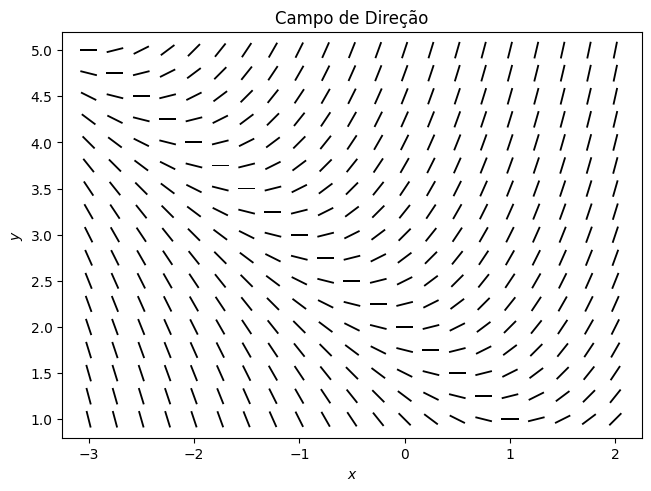

In [51]:
# Definindo cada dx como 1
dx = np.ones(X.shape)

# Calculo dos valores da função
dy = f(X, Y)

# Normalização do vetor usando distância euclidiana
[dx, dy] = [dx, dy] / np.sqrt(dx**2 + dy**2)

# Cria os objetos Figure e Axes
fig, ax = plt.subplots(layout="constrained")

# Plota um Campo vetorial 2D
quiver = ax.quiver(
    X, Y, dx, dy, headlength=0, headwidth=1, pivot="mid", label="_nolegend_"
)

# Config de legenda
ax.set_title(r'Campo de Direção')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.show()
# plt.savefig('cool_edo.png')

---

# Encapsulamento em classe Python

É muito legal ver todo esse passo a passo, mas o problema que eu preciso resolver é que eu tenho vários Campos de Diereção que precisam ser criados. Poder criá-los via alguma função seriá ótimo.

Agora é a hora de demonstrar minhas habilidades python de antes do ~~tempo do slop e queima de tokens~~, digo, tempo do Claude Code. É isso mesmo, nenuma ferramenta vibecoding foi usada aqui. Realmente fico orgulhoso de dizer isso.

## Encapsulamento via Python Dataclass

In [52]:
from dataclasses import dataclass
from typing import Callable

@dataclass
class LimitesGrafico:
    """ Classe que define os limites do gráfico """
    x_minimo: int
    x_maximo: int
    y_minimo: int
    y_maximo: int

@dataclass
class DistanciaPontos:
    """ Classe que define a distância entre os pontos do gráfico """
    dpx: float
    dpy: float

@dataclass
class CampoDirecao:
    f: Callable
    limites_grafico: LimitesGrafico
    distancia_pontos: DistanciaPontos

    @property
    def mesh(self):
        """ Gera os parâmetros da EDO ponto a ponto """
        return np.meshgrid(
            np.arange(
                self.limites_grafico.x_minimo,
                self.limites_grafico.x_maximo + self.distancia_pontos.dpx,
                self.distancia_pontos.dpx
            ),
            np.arange(
                self.limites_grafico.y_minimo,
                self.limites_grafico.y_maximo + self.distancia_pontos.dpy,
                self.distancia_pontos.dpy
            )
        )
        """
        Observação:
            Sacrificando um pouco de performance aqui tendo o mesh
            como propriedade para evitar ter que ficar atualizando o
            valor cacheado caso limites_grafico ou distancia_pontos mude.

            Poderia também usar @cached_property com setters
            definidos nos campos que podem mudar, mas isso
            está fora do escopo desse script
        """
    
    @property
    def pontos(self):
        """ Calcula os pontos e vetores de direção """

        X, Y = self.mesh

        # Definindo cada dx como 1
        dx = np.ones(X.shape)

        # Calculo dos valores da função
        dy = f(X, Y)

        # Normalização do vetor usando distância euclidiana
        [dx, dy] = [dx, dy] / np.sqrt(dx**2 + dy**2)

        return X, Y, dx, dy


    def plot_fig(self):
        """ Plota a figura a partir das definições acima """

        X, Y, dx, dy = self.pontos

        fig, ax = plt.subplots(layout="constrained")

        # Plota um Campo vetorial 2D
        quiver = ax.quiver(
            X, Y, dx, dy,
            headlength=0, headwidth=1, pivot="mid", label="_nolegend_"
        )

        # Config de legenda
        ax.set_title(r'Campo de Direção')
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        plt.show()

Com a classe pronta tudo que preciso é definir os objetos limites_grafico e distancia_pontos uma vez. A cada nova instância do CampoDircao eu passo os parâmetros de config, a EDO que quero mapear e vuá-lá.

## Execução da classe CampoDirecao

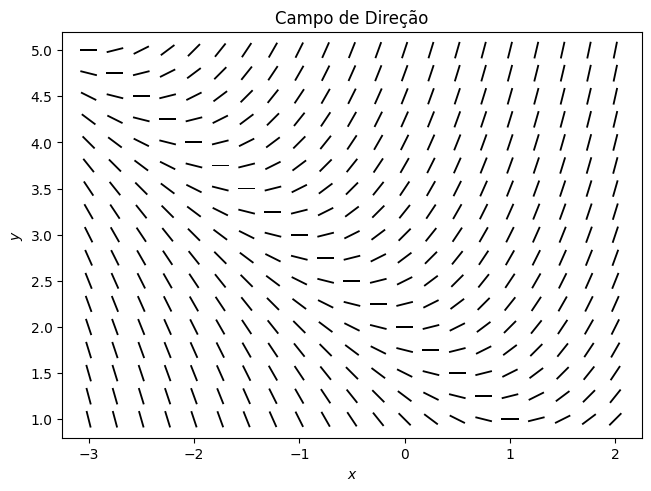

In [53]:
# Definição das configs da imagem do gráfico
limites_grafico = LimitesGrafico(x_minimo=-3, x_maximo=2, y_minimo=1, y_maximo=5)
distancia_pontos = DistanciaPontos(dpx=0.25, dpy=0.25)

# Definição da EDO que será mapeada
f = lambda x, y: -2 + x + y

# Criação do objeto CampoDirecao
cd = CampoDirecao(f=f, distancia_pontos=distancia_pontos, limites_grafico=limites_grafico)

# Execução do método que plota o gráfico
cd.plot_fig()


---

## Resolvendo os problemas do livro

Problema 1.1-4) Em cada um dos Problemas 1 a 4, desenhe um campo de direções para a equação diferencial dada.

- Problema 1.1: $y' = 3 - 2y$
- Problema 1.2: $y' = 2y - 3$
- Problema 1.3: $y' = -1 -2y$
- Problema 1.4: $y' = 1 + 2y$

In [54]:
# Defino apenas uma vez as configs da imagem
limites_grafico = LimitesGrafico(x_minimo=-3, x_maximo=2, y_minimo=1, y_maximo=5)
distancia_pontos = DistanciaPontos(dpx=0.25, dpy=0.25)

### Resolvendo o problema 1.1

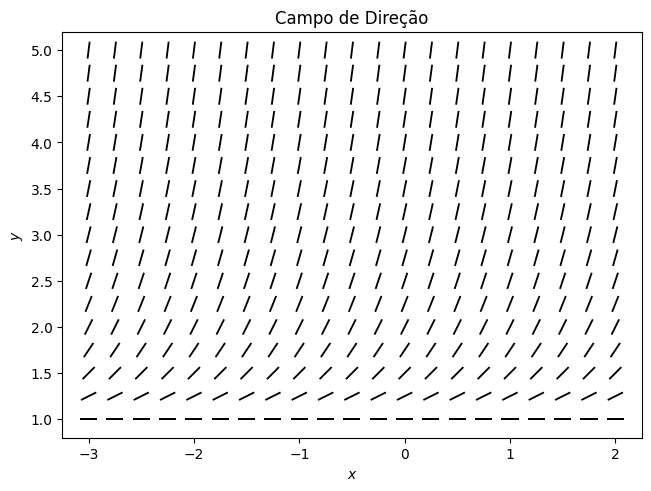

In [55]:
# Problema 1.1
f = lambda x, y: -2 + 0 * x + 2 * y

cd = CampoDirecao(f=f, distancia_pontos=distancia_pontos, limites_grafico=limites_grafico)

cd.plot_fig()


### Resolvendo o problema 1.2

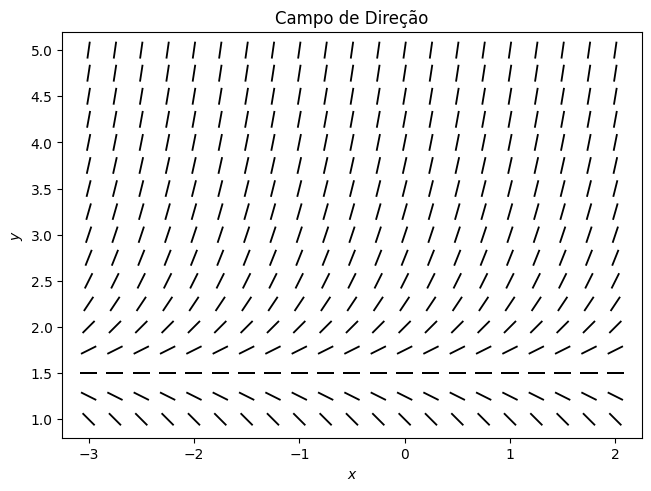

In [56]:
# Problema 1.2
f = lambda x, y: -3 + 0 * x + 2 * y

cd = CampoDirecao(f=f, distancia_pontos=distancia_pontos, limites_grafico=limites_grafico)

cd.plot_fig()


### Resolvendo o problema 1.3

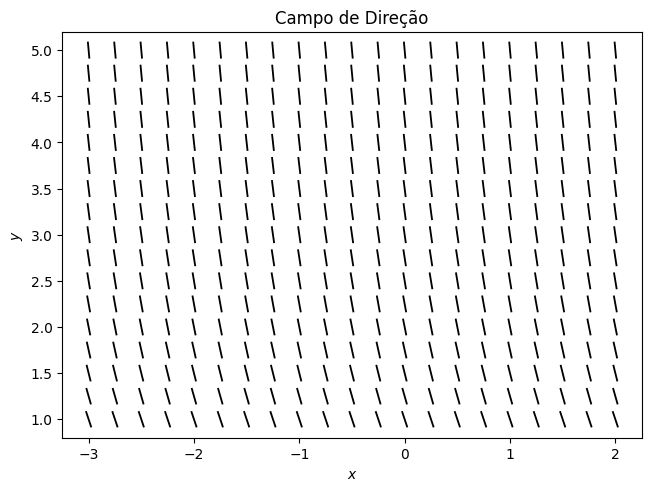

In [57]:
# Problema 1.3
f = lambda x, y: -1 + 0 * x + -2 * y

cd = CampoDirecao(f=f, distancia_pontos=distancia_pontos, limites_grafico=limites_grafico)

cd.plot_fig()


### Resolvendo o problema 1.4

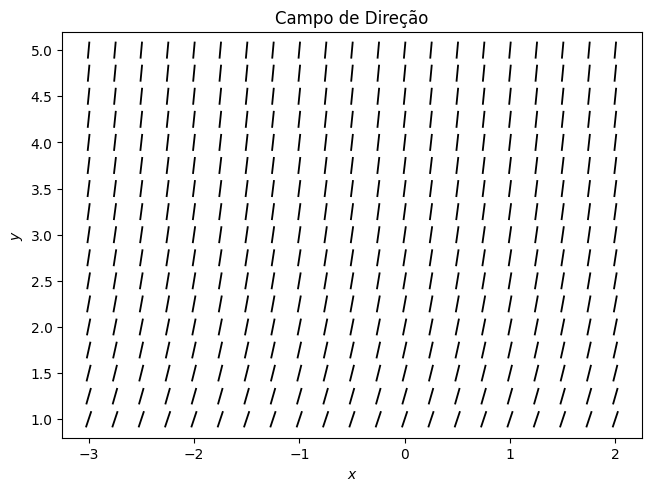

In [58]:
# Problema 1.4
f = lambda x, y: 1 + 0 * x + 2 * y

cd = CampoDirecao(f=f, distancia_pontos=distancia_pontos, limites_grafico=limites_grafico)

cd.plot_fig()


---

# Bibliografia e Referências

### Equações Diferenciais Elementares e Problemas de Valores de Contorno

O livro [Equações Diferenciais Elementares e Problemas de Valores de Contorno](https://www.amazon.com.br/Equa%C3%A7%C3%B5es-Diferenciais-Elementares-Problemas-Contorno/dp/8521636946) está sendo meu guia teórico sobre EDOs. Esse livro faz parte da bibliografia oficial do curso de [Introdução às Equações Diferenciais Ordinárias](https://gradmat.ufabc.edu.br/disciplinas/iedo/) da [UFABC](https://pt.wikipedia.org/wiki/Universidade_Federal_do_ABC), além de ser bem didático é divertido de acompanhar.

### Creating direction fields with Python por ethancsmith

Estou baseando a construção do plot python no item [Creating direction fields with Python](https://ethancsmith.github.io/math263-notes/01-direction_fields.html#creating-direction-fields-with-python) artigo [Direction fields](https://ethancsmith.github.io/math263-notes/01-direction_fields.html) de [ethancsmith](https://github.com/ethancsmith/math263-notes).

### Sobre a função $np.meshgrid$

É a primeira vez que estou usando a função [$np.meshgrid$](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html). Pelo que entendi inicialmente ela é o que usamos quando estamos trabalhando com funções de dois parâmetros.

Dois vídeos que eu assisti para entender melhor essa função foram:
- [The Python Function You NEED For 2D Data ](https://www.youtube.com/watch?v=sHwdoSQpMFQ&t=463s) do canal [Mr. P Solver](https://www.youtube.com/@MrPSolver)
- [How to use NUMPY MESHGRID and Contour Plots in Python](https://www.youtube.com/watch?v=wke3KZIog2Y) do canal [Dot Physics](https://www.youtube.com/@DotPhysics)

Depois de assistir os vídeos tudo ficou mais claro. O problema é que temos uma função com dois parametros, então precisamos de pares de x e y para calcular cada ponto do grafico que vamos plotar. Pense como os eixos x e y sendo o terreno, variáveis de input, e o resultado da função sendo a altura no eixo z.